# 02 Linear Regression

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Linear Regression
The most basic form of regression, and the simplest to understand, is linear regression. For $n$ features, contained in a vector $x=(1,x_1,x_2,...,x_n)$, linear regression involves fitting a straight line of the form:
$$
\hat{y} = h_{\theta} (x) = \theta \cdot x,
$$
where $\theta=(\theta_0,\theta_1,...,\theta_n)$ are the model's parameters. Note that we have included $x_0=1$ in our feature vector, and when taking the dot product this gives a $+\theta_0$ term, corresponding to the intercept or *bias* of the linear model. The $\hat{y}$ term is the predicted value that we output given that we input the vector $x$. (Additionally, we denote our model by $h_\theta(x)$, as this is our *hypothesis function*, meaning we are making an assumption about the form which our data takes.)


How do we choose the parameters? We need a *cost function*, which penalizes points lying away from our predicted line. As usual, we will use the *Root Mean Square Error* (RMSE), however in practice we will actually be minimising the *Mean Square Error* (MSE) since the math is easier and it gives us the same result:
$$
\mathrm{MSE}(X,h_{\theta}) = \frac{1}{m} \sum_{i=1}^m \left( \theta^T x^{(i)} - y^{(i)} \right)^2.
$$
Here, we have taken the summation over the $m$ instances (i.e. datapoints) that we have available, where $x^{(i)}$ and $y^{(i)}$ represent the $i^{\mathrm{th}}$ instance.


### 1.1. The Normal Equation

Rather nicely, linear regression in combination with the MSE cost function actually has a closed form solution, known as the *normal equation*:
$$
\hat{\theta} = (X^T X)^{-1} X^T y
$$


Normal Equation:
[[7.6403144 ]
 [4.57861043]]
Scikit-Learn:
[7.6403144]
[[4.57861043]]


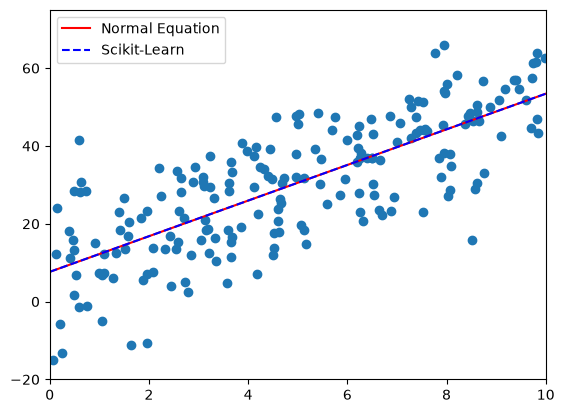

In [153]:
Xmax = 10       # Maximum X value
intercept = 5  # intercept of slope
slope = 5      # gradient of slope
randScale = 10  # scale of random data
num_data = 200

# Generate Data
X = Xmax * np.random.rand(num_data, 1)
y = intercept + slope * X + randScale * np.random.randn(num_data,1)

# Normal Equation
X_b = np.c_[np.ones((num_data, 1)), X] # adds x0 = 1 to each data point
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print("Normal Equation:")
print(theta_best)

# Predictions using our Normal Equation:
X_new = np.array([[0], [Xmax]])
X_new_b = np.c_[np.ones((2,1)), X_new]
y_predict = X_new_b.dot(theta_best)


# Alternatively, we can use Scikit-Learn's Linear Regression model:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_sklearn_predict = lin_reg.predict(X_new)
print("Scikit-Learn:")
print(lin_reg.intercept_)
print(lin_reg.coef_)

# Plot data and linear fit
plt.scatter(X,y)
plt.plot(X_new, y_predict, "r-", label="Normal Equation")
plt.plot(X_new, y_sklearn_predict,"b--", label="Scikit-Learn")
plt.axis([0, Xmax, -2*randScale, Xmax*slope + intercept + 2*randScale])
plt.legend()
plt.show()

We can alternatively apply Linear Regression using Scikit-Learn. However there is an important difference between what we did above and what Scikit-Learn does:
- When we calculated the normal equation by hand, we took the inverse of $X^T X$ via the np.linalg library. This will only work is $X^T X$ is non-singular. Also, it scales as $\sim \mathcal{O}(n^3)$
- In contrast, Scikit-Learn utilizes the pseudo-inverse, calculated via SVD, which is always defined. This scales as $\mathcal{O}(n^2)$, so we would pretty much always in practice use this method.

Note that the most important feature of sklearn's 

### 1.2 Polynomial Regression

If our model is more complex than a straight line, we can actually still use Linear Regression to fit by adding polynomial features. This extends our features $x$ to contain higher powers such as $x^2$, $x^3$, ..., which we then use Linear Regression to fit.

There are two important ideas that we must take note of here:
1. Adding polynomial features for multiple features, say $a$ and $b$, doesn't just take higher powers of our features individually, it also takes all combinations. For example, $a$ and $b$ up to degree $2$ gives $a^2$, $ab$, and $b^2$. This is very important, since it means it is capable of finding relationships between features.
2. Because polynomial features takes all combinations up to the specified power, incorporating polynomial features of degree $d$ for $n$ features gives $(n+d)! / d! n!$ new features. This can be an enormous number, which we need to be careful of.

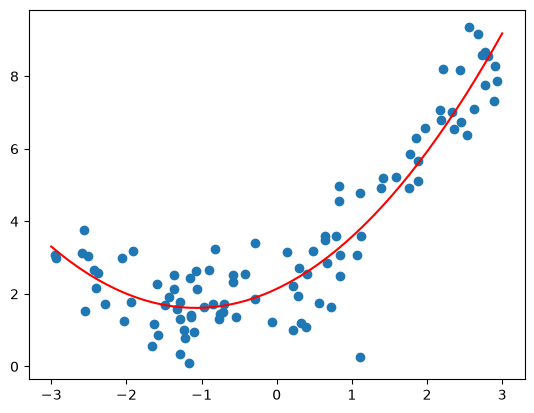

In [217]:
# Generate quadratic data
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m,1)

# Add polynomial features
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Fit via Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

# Plot fit
intercept = lin_reg.intercept_
x_1_coef = lin_reg.coef_[0][0]
x_2_coef = lin_reg.coef_[0][1]
X_plot = np.linspace(-3,3)
y_plot = x_2_coef * X_plot**2 + x_1_coef * X_plot + intercept
plt.scatter(X,y)
plt.plot(X_plot, y_plot, "r-")

plt.show()